In [115]:
from fpl_project.scripts import config
from fpl_project.scripts.data_utils.features_config import FeaturesConfig
from fpl_project.scripts.model_utils.data import FPLDataPipe, train_test_split
from fpl_project.scripts.model_utils.trainer import set_seed
from fpl_project.scripts.model_utils.selector import ModelSelector, initialize_device


In [116]:
import pandas as pd

pd.set_option('display.max_columns', None)
import seaborn as sns
sns.set_style("whitegrid")
import glum


In [117]:
device = initialize_device()
device

'cpu'

In [118]:
set_seed(77)
data = pd.read_parquet(config.FPL_DATA_PATH)
data.total_points = data.total_points.clip(lower=0)

In [102]:
cols_map = FeaturesConfig()
ignored_num = {"name", "position", "element", "opponent_team", "gw", "code", "season", "kickoff_time", "team"}
ignored_cat = {"web_name", "player_id", "gw"}
data_cols_set = set(data.columns)

ema_lagg_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
pre_game_filtered = [c for c in getattr(cols_map, "pre_game_cols") if c in data_cols_set and c not in ignored_num]
num_cols = list(dict.fromkeys(ema_lagg_cols + pre_game_filtered))
cat_cols = [c for c in getattr(cols_map, "static_cols") if c in data_cols_set and c not in ignored_cat]




In [103]:
fpl_data_pipe = FPLDataPipe(num_cols=num_cols, cat_cols=cat_cols)


In [104]:
data_splits = train_test_split(data)


In [105]:
data_splits["X_train"] = fpl_data_pipe.preprocessor.fit_transform(data_splits.get("X_train"))
data_splits["X_valid"] = fpl_data_pipe.preprocessor.transform(data_splits.get("X_valid"))
data_splits["X_test"] = fpl_data_pipe.preprocessor.fit_transform(data_splits.get("X_test"))


In [106]:
data_splits.keys()

dict_keys(['X_train', 'y_train', 'X_valid', 'y_valid', 'X_test', 'y_test'])

In [107]:
glm = glum.GeneralizedLinearRegressor(
    family="negative.binomial",
    link="auto", 
    alpha=2,
    l1_ratio=0.5,
    
)

In [108]:
glm.fit(X=data_splits.get("X_train"), y=data_splits.get("y_train"))

,alpha,2
,l1_ratio,0.5
,P1,'identity'
,P2,'identity'
,fit_intercept,True
,family,'negative.binomial'
,link,'auto'
,solver,'auto'
,max_iter,100
,max_inner_iter,100000
,gradient_tol,None


In [114]:
glm.score(X=data_splits.get("X_valid"), y=data_splits.get("y_valid"))

-0.00018710674863609

In [110]:
y_pred = glm.predict(data_splits.get("X_test"))

<Axes: ylabel='Count'>

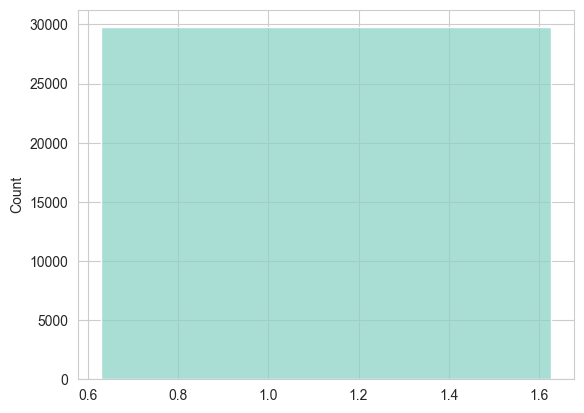

In [111]:
sns.histplot(x=y_pred, discrete=True)

<Axes: xlabel='coef', ylabel='feature'>

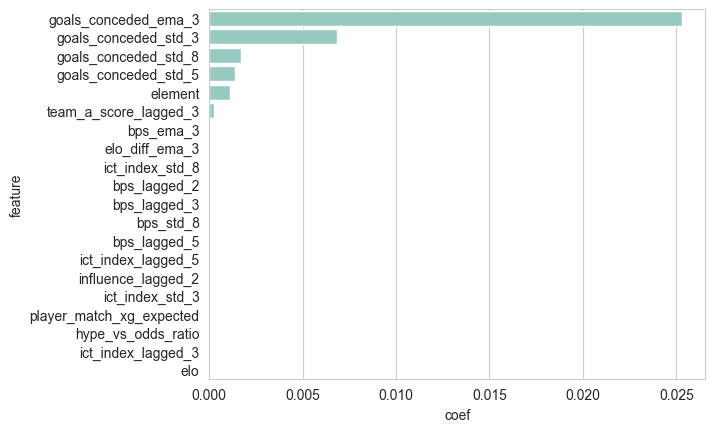

In [112]:
sns.barplot(data=coefs.sort_values(by="coef", ascending=False).head(20), x="coef", y="feature")

In [113]:
coefs.sort_values()

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'